# Basic EDA: SPX options, Q2 2023

This notebook analyzes `cleaned files/spx_options_filtered_2023q2.csv`, the saved output of `prelim.ipynb`. It reads the file as saved and does not rerun its filters. Plots are descriptive, and percentile limits used in plots do not remove rows from the analysis.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
source = Path("cleaned files") / "spx_options_filtered_2023q2.csv"
df = pd.read_csv(source, parse_dates=["QUOTE_DATE", "EXPIRE_DATE"])
df["REL_SPREAD"] = (df["ASK"] - df["BID"]) / df["MID_PRICE"]
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
print(f"Quote dates: {df['QUOTE_DATE'].min():%Y-%m-%d} to {df['QUOTE_DATE'].max():%Y-%m-%d}")
display(df.head())

Rows: 409,623 | Columns: 14
Quote dates: 2023-04-03 to 2023-06-30


,QUOTE_DATE,EXPIRE_DATE,OPTION_TYPE,DTE,UNDERLYING_LAST,STRIKE,BID,ASK,VOLUME,IV,MID_PRICE,STRIKE_TO_SPOT,MONEYNESS,REL_SPREAD
0,2023-04-03,2023-04-05,CALL,2.0,4123.95,3350.0,775.5,778.6,2.0,1.10649,777.05,0.812328,ITM,0.003989
1,2023-04-03,2023-04-05,CALL,2.0,4123.95,3400.0,725.5,728.6,10.0,1.03568,727.05,0.824452,ITM,0.004264
2,2023-04-03,2023-04-05,CALL,2.0,4123.95,3450.0,675.5,678.6,2.0,0.96605,677.05,0.836577,ITM,0.004579
3,2023-04-03,2023-04-05,CALL,2.0,4123.95,3550.0,575.3,578.5,1.0,0.81691,576.90,0.860825,ITM,0.005547
4,2023-04-03,2023-04-05,CALL,2.0,4123.95,3600.0,525.5,528.6,1.0,0.75967,527.05,0.872949,ITM,0.005882


## Coverage and data quality

Check missing values, duplicate contracts, valid quotes, and whether the saved observations meet the numerical filters.

In [2]:
quality = pd.Series({
    "Missing cells": int(df.isna().sum().sum()),
    "Exact duplicate rows": int(df.drop(columns=["REL_SPREAD"]).duplicated().sum()),
    "Duplicate contract/date keys": int(df.duplicated(["QUOTE_DATE", "EXPIRE_DATE", "STRIKE", "OPTION_TYPE"]).sum()),
    "Nonpositive or nonfinite IV": int((~np.isfinite(df["IV"]) | df["IV"].le(0)).sum()),
    "Nonpositive bid or ask": int((df["BID"].le(0) | df["ASK"].le(0)).sum()),
    "Crossed quotes (bid > ask)": int(df["BID"].gt(df["ASK"]).sum()),
    "DTE outside 2-180": int((~df["DTE"].between(2, 180)).sum()),
    "Strike/spot outside 0.8-1.2": int((~df["STRIKE_TO_SPOT"].between(.8, 1.2)).sum()),
}, name="Count")
display(quality.to_frame())

,Count
Missing cells,0
Exact duplicate rows,0
Duplicate contract/date keys,0
Nonpositive or nonfinite IV,0
Nonpositive bid or ask,0
Crossed quotes (bid > ask),0
DTE outside 2-180,0
Strike/spot outside 0.8-1.2,0


## Composition and numerical summary

In [3]:
composition = pd.crosstab(df["OPTION_TYPE"], df["MONEYNESS"])
composition = composition.reindex(index=["CALL", "PUT"], columns=["ITM", "ATM", "OTM"], fill_value=0)
display(composition)
numeric_columns = ["DTE", "VOLUME", "IV", "MID_PRICE", "REL_SPREAD", "STRIKE_TO_SPOT"]
display(df[numeric_columns].describe(percentiles=[.05, .25, .5, .75, .95, .99]).T.round(4))

MONEYNESS,ITM,ATM,OTM
OPTION_TYPE,,,
CALL,101318,28159,67868
PUT,21085,27435,163758


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
DTE,409623.0,50.3743,46.7516,2.0000,4.0000,14.0000,31.0000,78.0000,150.0000,171.0400,180.0000
VOLUME,409623.0,59.3552,316.8108,1.0000,1.0000,2.0000,5.0000,21.0000,219.0000,1100.0000,39003.0000
IV,409623.0,0.1842,0.0801,0.0000,0.0992,0.1310,0.1704,0.2207,0.3150,0.4654,1.4180
MID_PRICE,409623.0,114.3408,167.2628,0.0750,0.4000,8.5500,43.5500,139.0000,506.9500,756.5500,962.6500
REL_SPREAD,409623.0,0.0524,0.1226,0.0014,0.0053,0.0098,0.0172,0.0370,0.2222,0.6667,1.4286
STRIKE_TO_SPOT,409623.0,0.9600,0.0679,0.8000,0.8366,0.9161,0.9674,1.0049,1.0621,1.1296,1.1998


## Contracts by option type and moneyness

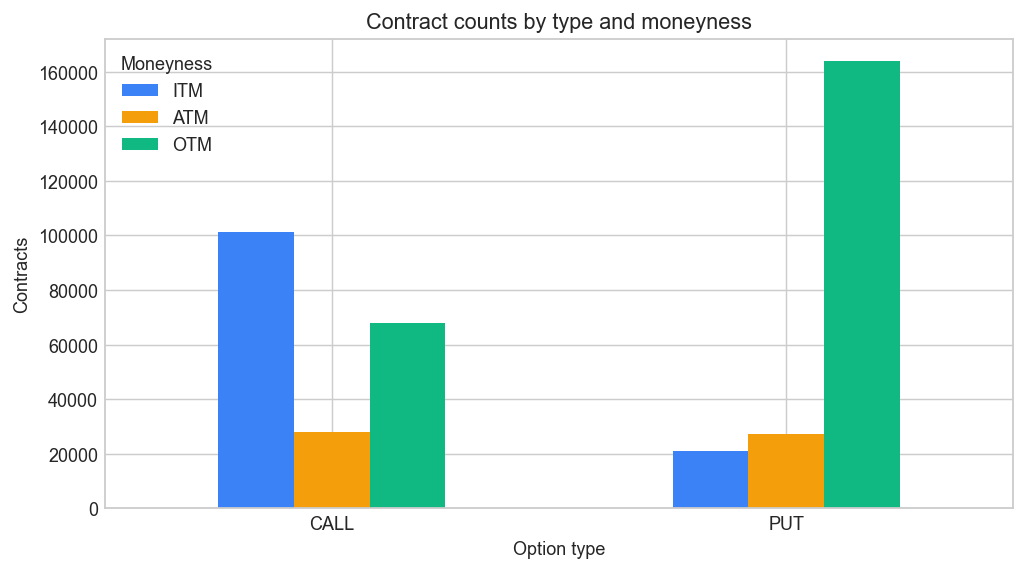

In [4]:
counts = pd.crosstab(df["OPTION_TYPE"], df["MONEYNESS"]).reindex(
    index=["CALL", "PUT"], columns=["ITM", "ATM", "OTM"], fill_value=0
)
ax = counts.plot.bar(figsize=(8, 4.5), rot=0, color=["#3b82f6", "#f59e0b", "#10b981"])
ax.set(title="Contract counts by type and moneyness", xlabel="Option type", ylabel="Contracts")
ax.legend(title="Moneyness")
plt.tight_layout()
plt.show()

## Activity over quote dates

The upper panel counts retained contract observations. The lower panel sums the `VOLUME` field across those observations.

Highest retained-volume date: 2023-06-30 (800,847)


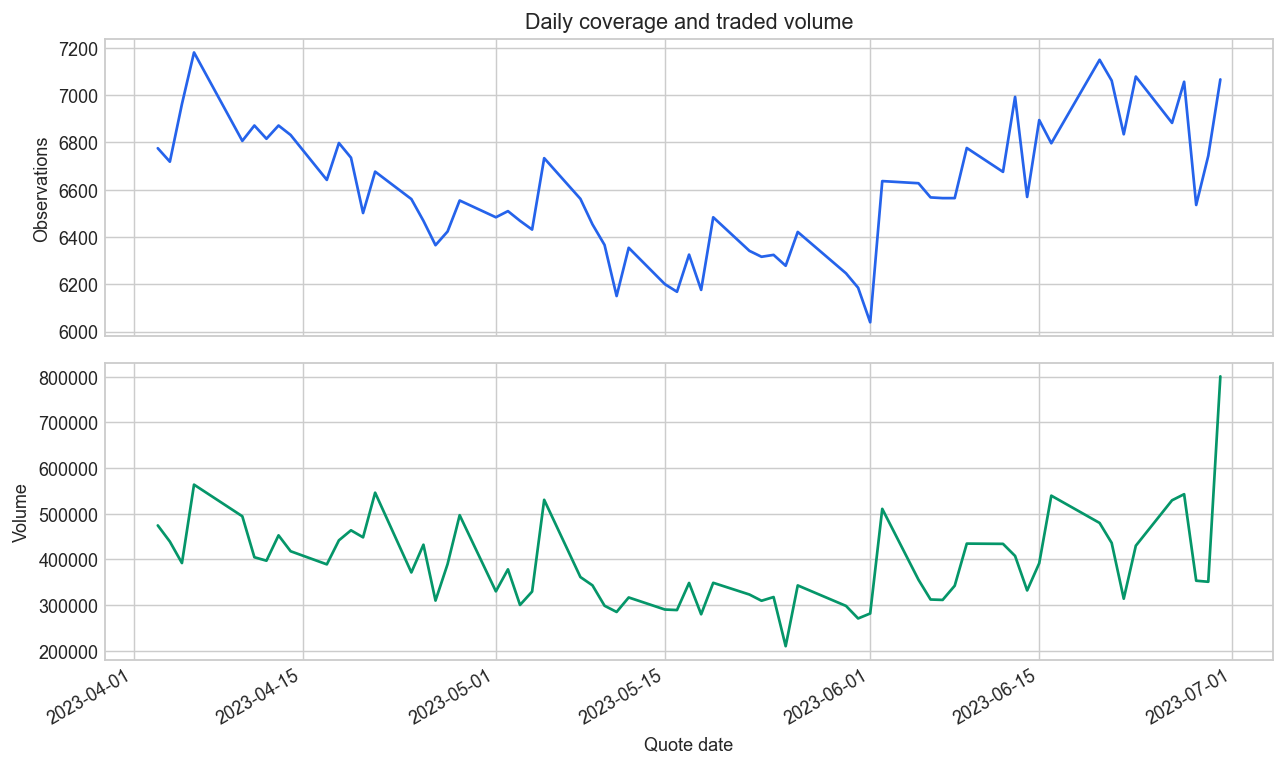

In [5]:
daily = df.groupby("QUOTE_DATE").agg(
    observations=("VOLUME", "size"), traded_volume=("VOLUME", "sum")
)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
daily["observations"].plot(ax=axes[0], color="#2563eb")
daily["traded_volume"].plot(ax=axes[1], color="#059669")
axes[0].set(ylabel="Observations", title="Daily coverage and traded volume")
axes[1].set(xlabel="Quote date", ylabel="Volume")
plt.tight_layout()
plt.show()
print(f"Highest retained-volume date: {daily['traded_volume'].idxmax():%Y-%m-%d} ({daily['traded_volume'].max():,.0f})")

## DTE distribution

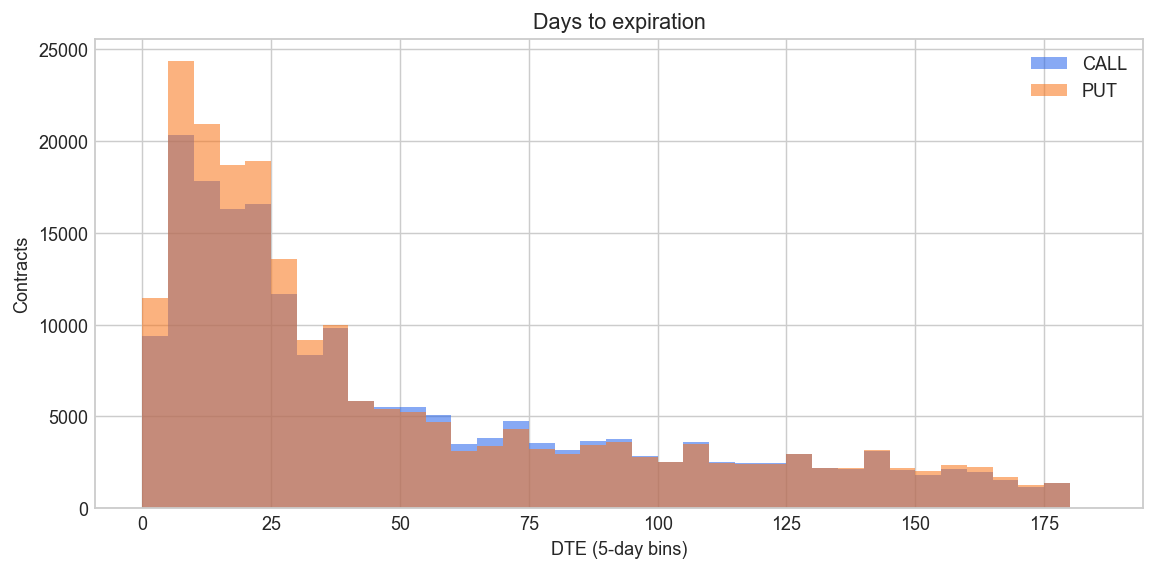

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.arange(0, 186, 5)
for option_type, color in [("CALL", "#2563eb"), ("PUT", "#f97316")]:
    ax.hist(df.loc[df["OPTION_TYPE"].eq(option_type), "DTE"],
            bins=bins, alpha=.55, label=option_type, color=color)
ax.set(title="Days to expiration", xlabel="DTE (5-day bins)", ylabel="Contracts")
ax.legend()
plt.tight_layout()
plt.show()

## Implied volatility distribution

The histogram displays IV values up to the 99th percentile for readability. The percentile is calculated from the full filtered file; values above it remain in all tables and other calculations.

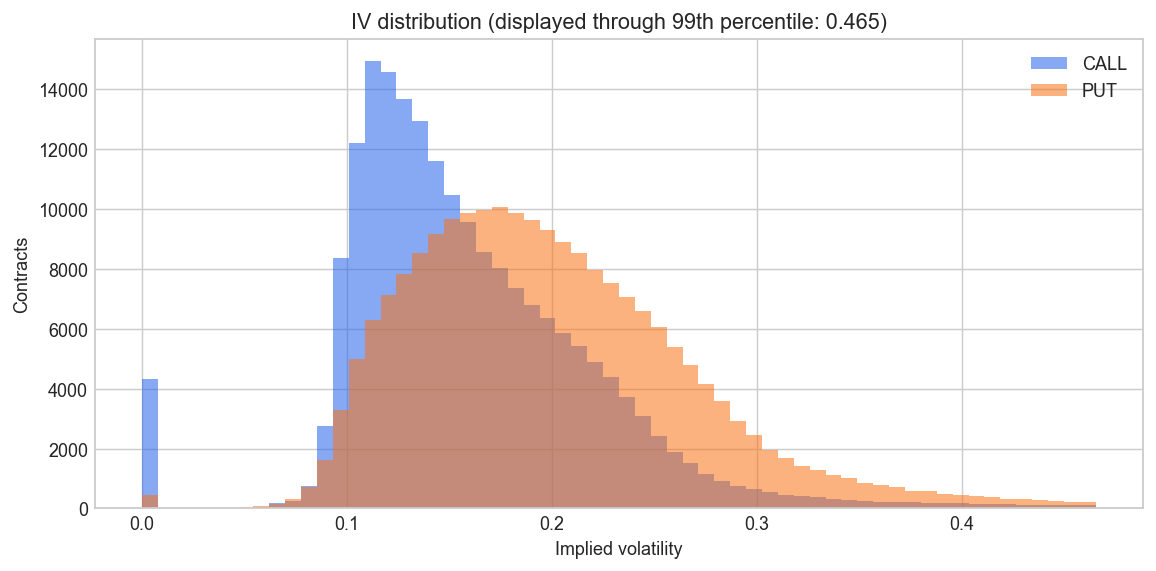

In [7]:
iv_limit = df["IV"].quantile(.99)
fig, ax = plt.subplots(figsize=(9, 4.5))
for option_type, color in [("CALL", "#2563eb"), ("PUT", "#f97316")]:
    values = df.loc[df["OPTION_TYPE"].eq(option_type) & df["IV"].le(iv_limit), "IV"]
    ax.hist(values, bins=60, alpha=.55, label=option_type, color=color)
ax.set(title=f"IV distribution (displayed through 99th percentile: {iv_limit:.3f})",
       xlabel="Implied volatility", ylabel="Contracts")
ax.legend()
plt.tight_layout()
plt.show()

## Median relative bid/ask spread

Relative spread is `(ASK - BID) / MID_PRICE`. This comparison uses all retained contracts.

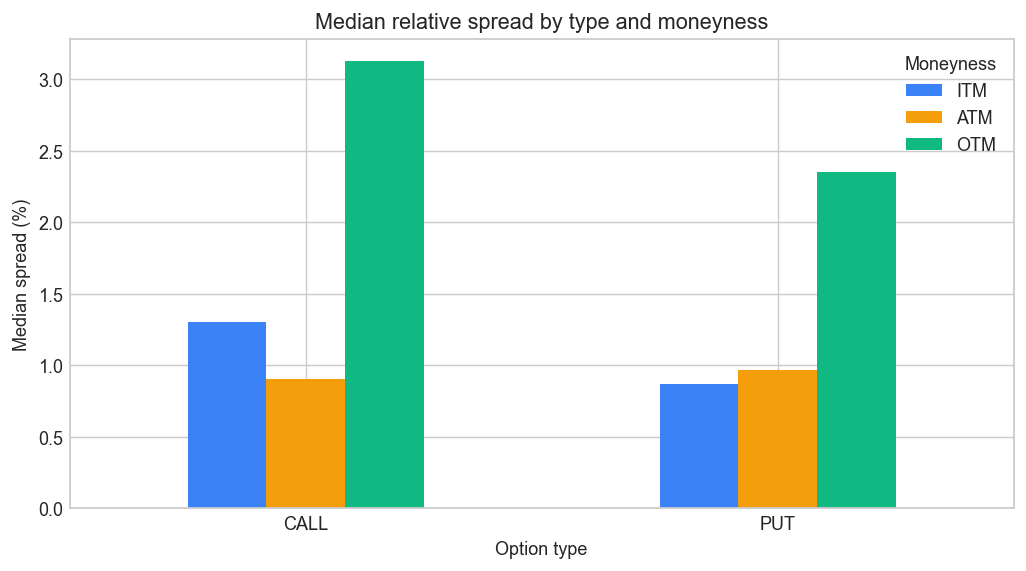

MONEYNESS,ITM,ATM,OTM
Option type,,,
CALL,1.30,0.90,3.13
PUT,0.87,0.97,2.35


In [8]:
spread = df.groupby(["OPTION_TYPE", "MONEYNESS"])["REL_SPREAD"].median().unstack()
spread = spread.reindex(index=["CALL", "PUT"], columns=["ITM", "ATM", "OTM"])
ax = (spread * 100).plot.bar(figsize=(8, 4.5), rot=0,
                             color=["#3b82f6", "#f59e0b", "#10b981"])
ax.set(title="Median relative spread by type and moneyness",
       xlabel="Option type", ylabel="Median spread (%)")
ax.legend(title="Moneyness")
plt.tight_layout()
plt.show()
display((spread * 100).round(2).rename_axis("Option type"))

## Volume distribution

The logarithmic x-axis makes low- and high-volume contracts visible together.

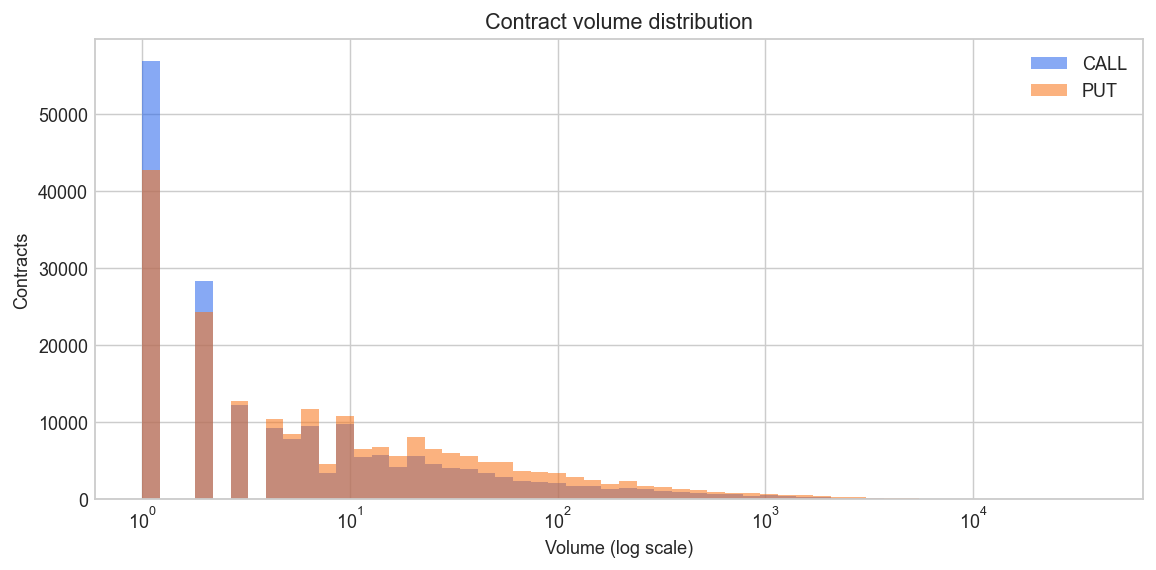

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
volume_bins = np.logspace(0, np.log10(df["VOLUME"].max()), 55)
for option_type, color in [("CALL", "#2563eb"), ("PUT", "#f97316")]:
    ax.hist(df.loc[df["OPTION_TYPE"].eq(option_type), "VOLUME"],
            bins=volume_bins, alpha=.55, label=option_type, color=color)
ax.set_xscale("log")
ax.set(title="Contract volume distribution", xlabel="Volume (log scale)", ylabel="Contracts")
ax.legend()
plt.tight_layout()
plt.show()